# Day 1 – HyenaDNA Embeddings on GENCODE Transcripts

This notebook introduces how to use a **HyenaDNA** to extract embeddings from real human transcript sequences and visualize the biological structure captured by these representations. You will work with a small subset of GENCODE transcripts, generate vector embeddings using a pre-trained model, and project them into 2D space to see how different transcript **biotypes** (e.g., protein-coding vs. lncRNA) separate in embedding space.

The goal is to connect the abstract idea of “sequence embeddings” to tangible biological patterns you can see and interpret.

---

### Biological Context

In this notebook, we focus on two transcript biotypes from GENCODE:

- **Protein-coding transcripts**  
  These serve as templates for proteins and must preserve open reading frames, codon structure, and other constraints related to translation.

- **Long non-coding RNAs (lncRNAs)**  
  These transcripts generally do not encode proteins but can have regulatory roles (e.g., chromatin organization, transcriptional regulation). They lack the same coding constraints and often have different sequence characteristics.

Even though the model is not explicitly told which sequences are protein-coding or lncRNA, its embeddings often cluster these two classes separately. This reflects the model’s ability to learn **sequence “grammar”** and functional signals from large-scale pre-training.

### Validate current environment and working directory

In [1]:
import os

conda_env = os.environ.get("CONDA_DEFAULT_ENV")
cwd = os.getcwd()

print(f"Conda envronment {conda_env}")
print(f"Current working directory: {cwd}")

Conda envronment gw-unified
Current working directory: /home/ullahi/src/github/gfm-workshop/jupyter-notebooks/1.day1_before_lunch


## Step 1: Data preparation
   - Parse a gzipped GENCODE FASTA file.
   - Extract a target number of sequences per biotype
        - In current case Protein Coding and lncRNA  
   - Optionally create a balanced subset (e.g., 100 protein-coding + 100 lncRNA).

In [18]:
import gzip
from Bio import SeqIO

# Paths
input_fasta = "../../data/gencode.v44.transcripts.fa.gz"
output_fasta = "../../output/gencode.v44.100_protein_coding_and_100_lncRNA.fa"

# Configuration
target_biotypes = {"protein_coding", "lncRNA"}
limits = {"protein_coding": 200, "lncRNA": 200}
counts = {biotype: 0 for biotype in target_biotypes}

# Process and write in a single pass
with gzip.open(input_fasta, "rt") as handle, open(output_fasta, "w") as out_fh:
    for record in SeqIO.parse(handle, "fasta"):
        # Extract biotype from header (8th field in GENCODE)
        fields = record.description.split("|")
        if len(fields) >= 8:
            biotype = fields[7]
            
            # Check if biotype is targeted and below limit
            if biotype in target_biotypes and counts[biotype] < limits[biotype]:
                SeqIO.write(record, out_fh, "fasta")
                counts[biotype] += 1
        
        # Stop reading file once all targets are met
        if all(counts[b] >= limits[b] for b in target_biotypes):
            break

print(f"Extraction complete. Counts: {counts}")

Extraction complete. Counts: {'lncRNA': 200, 'protein_coding': 200}


## Step 2: Load model and tokenizer
   - Load the HyenaDNA model and tokenizer from Hugging Face:
     - `LongSafari/hyenadna-medium-160k-seqlen-hf`
   - Move the model to GPU if available.
   - Load fasta sequences for embedding

In [19]:
import torch
from transformers import AutoTokenizer, AutoModel
from Bio import SeqIO
import umap
import matplotlib.pyplot as plt
import numpy as np
import einops

# Load model and tokenizer
model_name = "LongSafari/hyenadna-medium-160k-seqlen-hf"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(model_name, trust_remote_code=True)

In [20]:
# Load FASTA sequences
records = list(SeqIO.parse(output_fasta, "fasta"))

# Extract labels based on biotype from header
labels = []
sequences = []

# Encode and embed sequences
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for record in records:
    fields = record.description.split("|")
    if len(fields) >= 8:
        biotype = fields[7]
        labels.append(biotype)
        sequences.append(str(record.seq).upper().replace("U", "T"))  # DNA only


## Step 3: Compute Embeddings
   - Convert DNA sequences to model tokens.
   - Compute embeddings using the model’s last hidden state.
   - Apply mean pooling over the sequence dimension to get a single vector per transcript.

In [21]:
model.eval()

embeddings = []

with torch.no_grad():
    for seq in sequences:
        seq = seq[:300]  # Use first 300 bp 
        tokens = tokenizer(seq, return_tensors="pt", padding=True, truncation=True).to(device)
        outputs = model(**tokens)
        # Mean pooling over sequence dimension
        emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(emb[0])

embeddings = np.stack(embeddings)

## Step 4: Dimensionality reduction & visualization
   - Use UMAP and t-SNE to project embeddings to 2D.
   - Color points by biotype (protein-coding vs. lncRNA).
   - Inspect whether the model separates these biotypes in embedding space.

### tSNE-based visualization
<details>
<summary style="cursor: pointer; color: #2196F3; font-weight: bold;">
    Click to see UMAP Parameter Explanation
</summary>

<br>

#### UMAP Configuration Details:
- **`n_neighbors=10`**: Balances local vs. global structure. Low values focus on very local patterns.
- **`min_dist=0.1`**: Controls how tightly points are packed. 0.1 allows for distinct cluster grouping.
- **`metric="cosine"`**: Measures the angle between vectors. Ideal for high-dimensional or sparse data.
- **`random_state=42`**: Ensures the stochastic process is reproducible.

</details>

/home/ullahi/miniconda3/envs/gw-unified/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


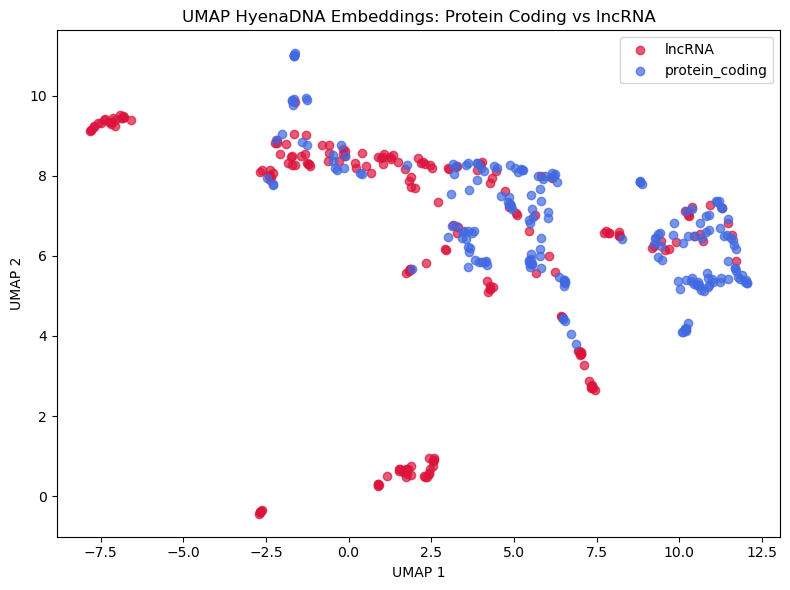

In [22]:
# Run UMAP
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42)
embeddings_umap = reducer.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8, 6))
colors = {"protein_coding": "royalblue", "lncRNA": "crimson"}

for label in set(labels):
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(embeddings_umap[idx, 0], embeddings_umap[idx, 1],
                label=label, alpha=0.7, color=colors.get(label, "gray"))

plt.legend()
plt.title("UMAP HyenaDNA Embeddings: Protein Coding vs lncRNA")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

### t-SNE-based visualization

<details>
<summary style="cursor: pointer; color: #2196F3; font-weight: bold;">
    Click to see t-SNE Parameter Explanation
</summary>

<br>

#### t-SNE Configuration Details:
- **`n_components=2`**: The dimension of the embedded space. This is the number of dimensions the data will be reduced to (2 for a standard 2D plot).
- **`perplexity=30`**: Related to the number of nearest neighbors used in manifold learning. Larger datasets usually require a higher perplexity; 30 is a standard default.
- **`max_iter=300`**: The maximum number of iterations for the optimization. (Note: In older versions of scikit-learn, this was named `n_iter`).
- **`random_state=42`**: Sets the seed for the random number generator, ensuring that the visualization is identical every time you run the code.

</details>


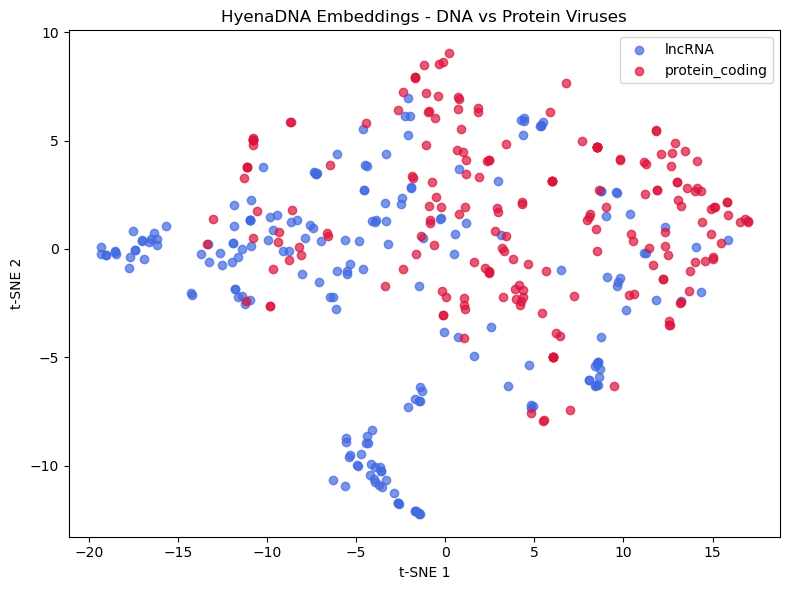

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)


# Plot
plt.figure(figsize=(8, 6))
colors = ["royalblue", "crimson"]
for i, label in enumerate(set(labels)):
    idx = [j for j, l in enumerate(labels) if l == label]
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label, alpha=0.7, color=colors[i])
plt.legend()
plt.title("HyenaDNA Embeddings - DNA vs Protein Viruses")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

--------------------

## Reflections

After going through the notebook, Try to answer below questions

#### What types of patterns in DNA sequence might the model be using to separate these biotypes?

<details>
<summary style="cursor: pointer">
    Click to see answer
</summary>

The model likely uses codon periodicity (the repeating 3-nucleotide pattern in coding sequences), ORF length distributions, and k-mer frequencies that differ between coding and non-coding transcripts. Protein-coding sequences must avoid premature stop codons and maintain reading frame, creating distinctive patterns the model learns during pre-training. Additionally, regulatory motifs like Kozak sequences near start codons provide strong signals for protein-coding classification.

</details>

#### How could you use similar embeddings for your own downstream tasks (classification, clustering, anomaly detection)
<details>
<summary style="cursor: pointer">
    Click to see answer
</summary>

1. We could use these embeddings as input features for a classifier to predict whether novel transcripts from RNA-seq data are likely protein-coding or regulatory.
2. For clustering, we could group functionally similar lncRNAs even if they lack sequence homology.
3. In anomaly detection, we could flag contaminating sequences or annotation errors by identifying outliers in embedding space.

</details>

#### What limitations do you see in this small-scale experiment, and how would you scale it up?
<details>
<summary style="cursor: pointer">
    Click to see answer
</summary>

Major limitations include: 
1. Small sample size (100/biotype) doesn't capture full diversity. For real applications, we need to scale to 10,000+ examples per biotype.
2. Truncating to 300bp loses information. For real applications, we need to use full sequences per biotype
</details>

---